# URBAN FLOOD STRESS | NOAA Tides

Objetivo:
- Descargar series de nivel desde NOAA desde 2010-01-01.
- Cargar estaciones, graficar ubicacion y construir Thiessen recortado a NYC.
- Guardar series y geometria en formatos limpios.

Fuentes:
- CO-OPS Data Retrieval API para las series.
- CO-OPS Metadata API para los metadatos de estaciones.
- `data/spatial/vector/nyc_borough_boundary/nybb.geojson` para el maximo contorno de NYC.

Notas:
- Estaciones primarias: 8531680, 8518750 y 8516945.
- Estaciones auxiliares: 8519461, 8517986, n06010, n07010, n03020, 8519532 y 8530973.
- El downloader intenta primero `hourly_height`, luego `high_low`, y por ultimo `air_gap`.
- Si NOAA expone una referencia de clearance en metadata, la conversion de `air_gap` a nivel queda automatizada.

In [1]:
from __future__ import annotations

import os
import time
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import requests

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import voronoi_polygons
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.validation import make_valid

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
session = requests.Session()
session.headers.update({'User-Agent': 'urban-flood-stress/1.0'})


def find_project_root() -> Path:
    """Locate the repository root from any notebook working directory."""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'data').exists():
            return candidate
    return current


ROOT = find_project_root()
SPATIAL_OUTPUT_DIR = ROOT / 'data' / 'spatial' / 'vector' / 'noaa'
TEMPORAL_OUTPUT_DIR = ROOT / 'data' / 'temporal' / 'noaa'
CACHE_DIR = TEMPORAL_OUTPUT_DIR / 'cache'
for folder in (SPATIAL_OUTPUT_DIR, TEMPORAL_OUTPUT_DIR, CACHE_DIR):
    folder.mkdir(parents=True, exist_ok=True)


def year_chunks(start_date, end_date):
    """Split a date range into calendar-year chunks."""
    start = pd.Timestamp(start_date).date()
    end = pd.Timestamp(end_date).date()
    cursor = start
    while cursor <= end:
        chunk_end = date(cursor.year, 12, 31)
        if chunk_end > end:
            chunk_end = end
        yield cursor.isoformat(), chunk_end.isoformat()
        cursor = chunk_end + timedelta(days=1)


def request_json(url, params=None, headers=None, retries=3, pause=1.0):
    """Fetch JSON with small retry/backoff handling."""
    params = params or {}
    headers = headers or {}
    last_error = None
    for attempt in range(retries):
        response = session.get(url, params=params, headers=headers, timeout=120)
        if response.status_code == 204:
            return {}
        if response.status_code in {429, 500, 502, 503, 504} and attempt < retries - 1:
            time.sleep(pause * (attempt + 1))
            continue
        try:
            response.raise_for_status()
        except Exception as exc:
            last_error = exc
            break
        try:
            payload = response.json()
        except ValueError as exc:
            raise RuntimeError(f'Non-JSON response from {url}: {response.text[:250]}') from exc
        if isinstance(payload, dict) and payload.get('error'):
            error = payload['error']
            if isinstance(error, dict):
                error = error.get('message') or error.get('description') or error
            raise RuntimeError(f'NOAA error for {url}: {error}')
        return payload
    if last_error is not None:
        raise RuntimeError(f'Request failed for {url}: {last_error}') from last_error
    raise RuntimeError(f'Unable to fetch {url}')


def extract_station_record(payload):
    """Normalize the different NOAA station payload shapes."""
    if not isinstance(payload, dict):
        return {}
    if 'id' in payload and ('lat' in payload or 'lng' in payload or 'name' in payload):
        return payload
    for key in ('station', 'stations', 'stationList', 'stationlist'):
        value = payload.get(key)
        if isinstance(value, dict):
            return value
        if isinstance(value, list) and value:
            return value[0]
    return payload


def first_float(mapping, keys):
    """Return the first numeric value found under a list of keys."""
    for key in keys:
        if not isinstance(mapping, dict):
            continue
        value = mapping.get(key)
        if value in (None, ''):
            continue
        try:
            return float(value)
        except (TypeError, ValueError):
            continue
    return None


def deep_find_float(obj, keys):
    """Recursively search nested NOAA payloads for a numeric field."""
    if isinstance(obj, dict):
        for key in keys:
            if key in obj:
                value = obj[key]
                if value in (None, ''):
                    continue
                try:
                    return float(value)
                except (TypeError, ValueError):
                    pass
        for value in obj.values():
            found = deep_find_float(value, keys)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for value in obj:
            found = deep_find_float(value, keys)
            if found is not None:
                return found
    return None


def set_map_extent(ax, geom, pad=0.03):
    """Set a small padded view around a geometry."""
    minx, miny, maxx, maxy = geom.bounds
    dx = (maxx - minx) * pad
    dy = (maxy - miny) * pad
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)



def load_nyc_boundary():
    """Load the NYC borough polygons and a valid union geometry."""
    nyc = gpd.read_file(ROOT / 'data' / 'spatial' / 'vector' / 'nyc_borough_boundary' / 'nybb.geojson')
    nyc = nyc.copy()
    nyc['geometry'] = nyc.geometry.apply(make_valid)
    city = unary_union(nyc.geometry)
    return nyc, city



def build_thiessen(points_gdf, clip_geom):
    """Build Thiessen polygons, clipped to the NYC union geometry."""
    if len(points_gdf) < 2:
        raise ValueError('Se necesitan al menos dos estaciones para construir Thiessen.')
    diagram = voronoi_polygons(
        unary_union(points_gdf.geometry),
        extend_to=clip_geom,
        ordered=True,
    )
    rows = []
    base_rows = points_gdf.drop(columns='geometry').to_dict('records')
    for record, cell in zip(base_rows, diagram.geoms):
        clipped = cell.intersection(clip_geom)
        if clipped.is_empty:
            continue
        record = dict(record)
        record['geometry'] = clipped
        rows.append(record)
    return gpd.GeoDataFrame(rows, crs=points_gdf.crs)

In [3]:
TIDE_STATIONS = pd.DataFrame(
    [
        {'station_id': '8531680', 'station_name': 'Sandy Hook, NJ', 'role': 'primary'},
        {'station_id': '8518750', 'station_name': 'The Battery, NY', 'role': 'primary'},
        {'station_id': '8516945', 'station_name': 'Kings Point, NY', 'role': 'primary'},
        {'station_id': '8519461', 'station_name': 'Bayonne Bridge Air Gap, NY', 'role': 'auxiliary'},
        {'station_id': '8517986', 'station_name': 'Verrazano-Narrows Air Gap, NY', 'role': 'auxiliary'},
        {'station_id': 'n06010', 'station_name': 'Kill Van Kull LB 14', 'role': 'auxiliary'},
        {'station_id': 'n07010', 'station_name': 'Newark Bay Entrance LB 18', 'role': 'auxiliary'},
        {'station_id': 'n03020', 'station_name': 'The Narrows', 'role': 'auxiliary'},
        {'station_id': '8519532', 'station_name': 'Mariners Harbor, NY', 'role': 'auxiliary'},
        {'station_id': '8530973', 'station_name': 'Robbins Reef, NJ', 'role': 'auxiliary'},
    ]
)

COOPS_MDAPI_BASE = 'https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations'
COOPS_DATA_URL = 'https://api.tidesandcurrents.noaa.gov/api/prod/datagetter'
START_DATE = '2010-01-01'
END_DATE = date.today().isoformat()
TIDE_CACHE_DIR = CACHE_DIR / 'tides'
TIDE_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def fetch_station_metadata(station_row):
    """Get a compact metadata record for a NOAA CO-OPS station."""
    station_id = station_row['station_id']
    fallback_name = station_row['station_name']
    payload = request_json(
        f'{COOPS_MDAPI_BASE}/{station_id}.json',
        params={'expand': 'details,products,datums'},
    )
    record = extract_station_record(payload)
    if not record:
        raise RuntimeError(f'No metadata returned for station {station_id}')
    candidate_keys = [
        'bridge_clearance_ft',
        'bridge_clearance',
        'clearance_ft',
        'clearance',
        'air_gap_height_ft',
        'air_gap_height',
        'vertical_clearance_ft',
        'vertical_clearance',
    ]
    return {
        'station_id': str(record.get('id', station_id)),
        'station_name': record.get('name') or fallback_name,
        'role': station_row['role'],
        'lat': first_float(record, ['lat', 'latitude']),
        'lon': first_float(record, ['lng', 'lon', 'longitude']),
        'state': record.get('state') or record.get('stateCode'),
        'tidal': record.get('tidal'),
        'station_type': record.get('type') or record.get('stationType'),
        'bridge_clearance_ft': deep_find_float(record, candidate_keys),
    }



def fetch_tide_like_series(station_id, start_date, end_date):
    """Download tide-like data with a small priority ladder."""
    products = ('hourly_height', 'high_low', 'air_gap')
    for product in products:
        frames = []
        for chunk_start, chunk_end in year_chunks(start_date, end_date):
            params = {
                'station': station_id,
                'product': product,
                'begin_date': chunk_start.replace('-', ''),
                'end_date': chunk_end.replace('-', ''),
                'time_zone': 'gmt',
                'units': 'english',
                'format': 'json',
                'application': 'URBAN_FLOOD_STRESS',
            }
            if product != 'air_gap':
                params['datum'] = 'MLLW'
            try:
                payload = request_json(COOPS_DATA_URL, params=params)
            except Exception:
                continue
            rows = payload.get('data') or payload.get('results') or []
            if not rows:
                continue
            chunk = pd.DataFrame(rows)
            time_col = next((col for col in ('t', 'date_time', 'timestamp', 'date') if col in chunk.columns), None)
            value_col = next((col for col in ('v', 'water_level', 'air_gap', 'value') if col in chunk.columns), None)
            if time_col is None or value_col is None:
                continue
            chunk = chunk[[time_col, value_col]].rename(columns={time_col: 'timestamp', value_col: 'raw_value_ft'})
            chunk['timestamp'] = pd.to_datetime(chunk['timestamp'], errors='coerce', utc=True).dt.tz_convert(None)
            chunk['raw_value_ft'] = pd.to_numeric(chunk['raw_value_ft'], errors='coerce')
            chunk = chunk.dropna(subset=['timestamp', 'raw_value_ft'])
            if not chunk.empty:
                frames.append(chunk)
            time.sleep(0.1)
        if frames:
            out = pd.concat(frames, ignore_index=True)
            out['source_product'] = product
            out['value_unit'] = 'ft'
            return out
    return pd.DataFrame(columns=['timestamp', 'raw_value_ft', 'source_product', 'value_unit'])



def normalize_tide_series(raw, station_record):
    """Add station context and a tide-level column when possible."""
    if raw.empty:
        return raw
    out = raw.copy()
    source_product = out['source_product'].iat[0]
    bridge_clearance_ft = station_record['bridge_clearance_ft']
    out['station_id'] = station_record['station_id']
    out['station_name'] = station_record['station_name']
    out['role'] = station_record['role']
    out['lat'] = station_record['lat']
    out['lon'] = station_record['lon']
    out['state'] = station_record['state']
    out['station_type'] = station_record['station_type']
    out['bridge_clearance_ft'] = bridge_clearance_ft
    out['measurement_kind'] = {
        'hourly_height': 'water_level_ft',
        'high_low': 'high_low_ft',
        'air_gap': 'air_gap_ft',
    }.get(source_product, 'level_ft')
    out['tide_level_ft'] = out['raw_value_ft']
    if source_product == 'air_gap':
        if bridge_clearance_ft is not None:
            out['tide_level_ft'] = bridge_clearance_ft - out['raw_value_ft']
            out['series_kind'] = 'air_gap_to_tide'
        else:
            out['tide_level_ft'] = float('nan')
            out['series_kind'] = 'air_gap_raw'
    elif source_product == 'high_low':
        out['series_kind'] = 'observed_high_low'
    else:
        out['series_kind'] = 'observed_hourly'
    return out



def load_or_build_tide_series(station_record):
    """Cache one parquet per station so reruns stay fast."""
    cache_path = TIDE_CACHE_DIR / f"{station_record['station_id']}.parquet"
    if cache_path.exists():
        return pd.read_parquet(cache_path)
    raw = fetch_tide_like_series(station_record['station_id'], START_DATE, END_DATE)
    if raw.empty:
        return raw
    out = normalize_tide_series(raw, station_record)
    out.to_parquet(cache_path, index=False)
    return out

In [4]:
# Metadata y geometria de las estaciones.
tide_meta = []
for row in TIDE_STATIONS.to_dict('records'):
    try:
        tide_meta.append(fetch_station_metadata(row))
    except Exception as exc:
        tide_meta.append(
            {
                'station_id': row['station_id'],
                'station_name': row['station_name'],
                'role': row['role'],
                'lat': None,
                'lon': None,
                'state': None,
                'tidal': None,
                'station_type': None,
                'bridge_clearance_ft': None,
            }
        )
        print(f"Metadata faltante para {row['station_id']}: {exc}")

tide_catalog = pd.DataFrame(tide_meta)
tide_catalog['station_id'] = tide_catalog['station_id'].astype(str)
tide_catalog = tide_catalog.sort_values(['role', 'station_id'], kind='stable').reset_index(drop=True)
tide_catalog

,station_id,station_name,role,lat,lon,state,tidal,station_type,bridge_clearance_ft
0,8517986,Verrazano-Narrows Air Gap,auxiliary,40.606224,-74.044830,NY,True,None,None
1,8519461,Bayonne Bridge Air Gap,auxiliary,40.641970,-74.142110,NY,True,None,None
2,8519532,Mariners Harbor,auxiliary,40.638300,-74.160000,NY,True,None,None
3,8530973,Robbins Reef,auxiliary,40.658375,-74.064730,NJ,True,None,None
4,n03020,The Narrows,auxiliary,40.606400,-74.038002,NaN,None,None,None
5,n06010,Kill Van Kull LB 14,auxiliary,40.643580,-74.138890,NaN,None,None,None
6,n07010,Newark Bay Entrance LB 18,auxiliary,40.647080,-74.155500,NaN,None,None,None
7,8516945,Kings Point,primary,40.810300,-73.764900,NY,True,None,None
8,8518750,The Battery,primary,40.700554,-74.014170,NY,True,None,None
9,8531680,Sandy Hook,primary,40.466900,-74.009400,NJ,True,None,None


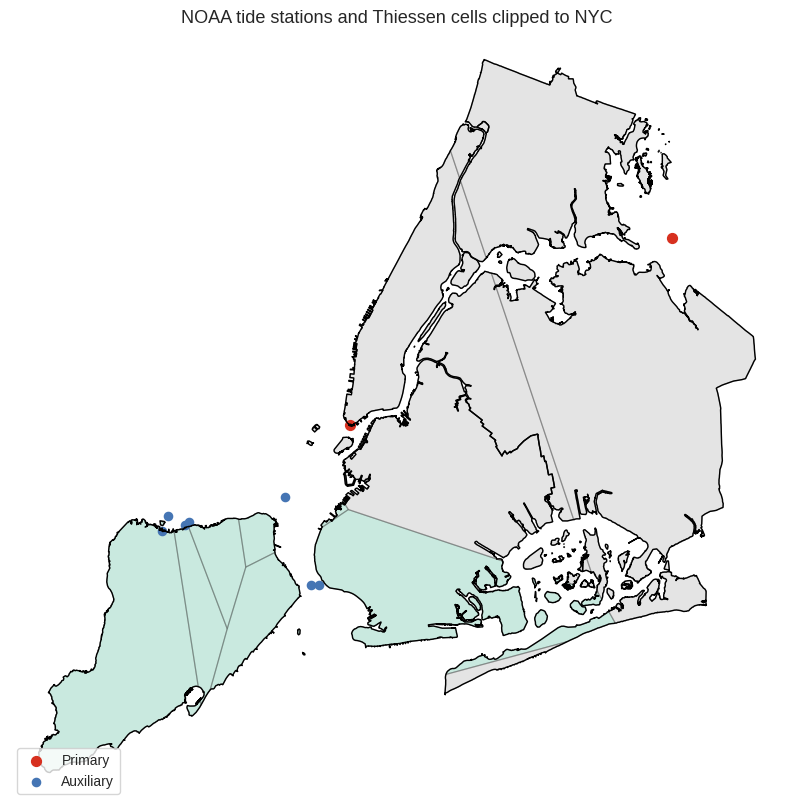

,station_id,station_name,role,geometry
0,8517986,Verrazano-Narrows Air Gap,auxiliary,"MULTIPOLYGON (((-74.15811 40.64287, -74.15813 ..."
1,8519461,Bayonne Bridge Air Gap,auxiliary,"MULTIPOLYGON (((-74.15135 40.63941, -74.15125 ..."
2,8519532,Mariners Harbor,auxiliary,"MULTIPOLYGON (((-74.13025 40.53872, -74.12882 ..."
3,8530973,Robbins Reef,auxiliary,"POLYGON ((-74.09502 40.61694, -74.10944 40.580..."
4,n03020,The Narrows,auxiliary,"MULTIPOLYGON (((-74.01554 40.65081, -74.02772 ..."
5,n06010,Kill Van Kull LB 14,auxiliary,"MULTIPOLYGON (((-74.10944 40.58065, -74.09502 ..."
6,n07010,Newark Bay Entrance LB 18,auxiliary,"MULTIPOLYGON (((-74.03766 40.63943, -74.03673 ..."
7,8516945,Kings Point,primary,"MULTIPOLYGON (((-73.92933 40.8458, -73.92933 4..."
8,8518750,The Battery,primary,"POLYGON ((-73.84608 40.57307, -73.84616 40.573..."
9,8531680,Sandy Hook,primary,"MULTIPOLYGON (((-73.81368 40.59078, -73.81363 ..."


In [5]:
# Mapa de ubicacion y Thiessen recortado a NYC.
nyc_boroughs, nyc_union = load_nyc_boundary()
tide_points = tide_catalog.dropna(subset=['lat', 'lon']).copy()
tide_points = gpd.GeoDataFrame(
    tide_points,
    geometry=gpd.points_from_xy(tide_points['lon'], tide_points['lat']),
    crs='EPSG:4326',
)
tide_thiessen = build_thiessen(tide_points, nyc_union)

fig, ax = plt.subplots(figsize=(10, 10))
nyc_boroughs.boundary.plot(ax=ax, color='black', linewidth=1)
tide_thiessen.plot(ax=ax, column='role', cmap='Set2', alpha=0.35, edgecolor='0.25', linewidth=0.9)
tide_points[tide_points['role'] == 'primary'].plot(ax=ax, color='#d7301f', markersize=50, label='Primary')
tide_points[tide_points['role'] == 'auxiliary'].plot(ax=ax, color='#4575b4', markersize=35, label='Auxiliary')
set_map_extent(ax, nyc_union, pad=0.04)
ax.set_title('NOAA tide stations and Thiessen cells clipped to NYC', fontsize=13)
ax.set_axis_off()
ax.legend(loc='lower left', frameon=True)
plt.show()

tide_thiessen[['station_id', 'station_name', 'role', 'geometry']]

In [6]:
# Guardar capas espaciales.
tide_points_out = SPATIAL_OUTPUT_DIR / 'tide_station_points.geojson'
tide_thiessen_out = SPATIAL_OUTPUT_DIR / 'tide_thiessen.geojson'
tide_points.to_file(tide_points_out, driver='GeoJSON')
tide_thiessen.to_file(tide_thiessen_out, driver='GeoJSON')
print(tide_points_out)
print(tide_thiessen_out)

/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/tide_station_points.geojson
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/tide_thiessen.geojson


In [7]:
# Descargar y cachear las series de nivel.
tide_series_list = []
tide_summary = []
for row in tide_catalog.to_dict('records'):
    series = load_or_build_tide_series(row)
    if series.empty:
        tide_summary.append(
            {
                'station_id': row['station_id'],
                'station_name': row['station_name'],
                'role': row['role'],
                'series_kind': 'none',
                'source_product': None,
                'rows': 0,
                'start': None,
                'end': None,
            }
        )
        continue
    tide_series_list.append(series)
    tide_summary.append(
        {
            'station_id': row['station_id'],
            'station_name': row['station_name'],
            'role': row['role'],
            'series_kind': series['series_kind'].iat[0],
            'source_product': series['source_product'].iat[0],
            'rows': int(len(series)),
            'start': series['timestamp'].min(),
            'end': series['timestamp'].max(),
        }
    )

tide_series = pd.concat(tide_series_list, ignore_index=True) if tide_series_list else pd.DataFrame()
tide_summary = pd.DataFrame(tide_summary)
tide_series

,timestamp,raw_value_ft,source_product,value_unit,station_id,station_name,role,lat,lon,state,station_type,bridge_clearance_ft,measurement_kind,tide_level_ft,series_kind
0,2010-01-01 00:00:00,0.472,hourly_height,ft,8516945,Kings Point,primary,40.8103,-73.7649,NY,None,None,water_level_ft,0.472,observed_hourly
1,2010-01-01 01:00:00,3.858,hourly_height,ft,8516945,Kings Point,primary,40.8103,-73.7649,NY,None,None,water_level_ft,3.858,observed_hourly
2,2010-01-01 02:00:00,6.998,hourly_height,ft,8516945,Kings Point,primary,40.8103,-73.7649,NY,None,None,water_level_ft,6.998,observed_hourly
3,2010-01-01 03:00:00,8.110,hourly_height,ft,8516945,Kings Point,primary,40.8103,-73.7649,NY,None,None,water_level_ft,8.110,observed_hourly
4,2010-01-01 04:00:00,8.163,hourly_height,ft,8516945,Kings Point,primary,40.8103,-73.7649,NY,None,None,water_level_ft,8.163,observed_hourly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426166,2026-03-31 19:00:00,0.350,hourly_height,ft,8531680,Sandy Hook,primary,40.4669,-74.0094,NJ,None,None,water_level_ft,0.350,observed_hourly
426167,2026-03-31 20:00:00,1.613,hourly_height,ft,8531680,Sandy Hook,primary,40.4669,-74.0094,NJ,None,None,water_level_ft,1.613,observed_hourly
426168,2026-03-31 21:00:00,2.853,hourly_height,ft,8531680,Sandy Hook,primary,40.4669,-74.0094,NJ,None,None,water_level_ft,2.853,observed_hourly
426169,2026-03-31 22:00:00,3.995,hourly_height,ft,8531680,Sandy Hook,primary,40.4669,-74.0094,NJ,None,None,water_level_ft,3.995,observed_hourly


In [8]:
# Resumen y guardado final.
tide_summary = tide_summary.sort_values(['role', 'station_id'], kind='stable').reset_index(drop=True)
tide_series_out = TEMPORAL_OUTPUT_DIR / 'tide_series.parquet'
tide_summary_out = TEMPORAL_OUTPUT_DIR / 'tide_summary.csv'
if not tide_series.empty:
    tide_series.to_parquet(tide_series_out, index=False)
tide_summary.to_csv(tide_summary_out, index=False)
print(tide_series_out)
print(tide_summary_out)
tide_summary

/home/map10194/Documents/urban-flood-stress/data/temporal/noaa/tide_series.parquet
/home/map10194/Documents/urban-flood-stress/data/temporal/noaa/tide_summary.csv


,station_id,station_name,role,series_kind,source_product,rows,start,end
0,8517986,Verrazano-Narrows Air Gap,auxiliary,none,NaN,0,NaT,NaT
1,8519461,Bayonne Bridge Air Gap,auxiliary,none,NaN,0,NaT,NaT
2,8519532,Mariners Harbor,auxiliary,none,NaN,0,NaT,NaT
3,8530973,Robbins Reef,auxiliary,none,NaN,0,NaT,NaT
4,n03020,The Narrows,auxiliary,none,NaN,0,NaT,NaT
5,n06010,Kill Van Kull LB 14,auxiliary,none,NaN,0,NaT,NaT
6,n07010,Newark Bay Entrance LB 18,auxiliary,none,NaN,0,NaT,NaT
7,8516945,Kings Point,primary,observed_hourly,hourly_height,142269,2010-01-01,2026-03-31 23:00:00
8,8518750,The Battery,primary,observed_hourly,hourly_height,142416,2010-01-01,2026-03-31 23:00:00
9,8531680,Sandy Hook,primary,observed_hourly,hourly_height,141486,2010-01-01,2026-03-31 23:00:00
